In [ ]:
from datetime import datetime, timedelta

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Constants
RISK_FREE_RATE = 0.04
SEED = 0 # for reproducibility

END_DATE = datetime.today()
START_DATE = END_DATE - timedelta(days=365*2)

In [4]:
np.random.seed(SEED)

tickers = ["MU", "EQIX", "ETN", "AMD", "EL", "WDC", "ANET"]

In [ ]:
class efficientFrontier:
    def __init__(self,
                 tickers,
                 start_date,
                 end_date
                 ):
        self.start_date = start_date
        self.end_date = end_date

        self.tickers = tickers
        # download data from yfinance
        prices = yf.download(self.tickers, start=self.start_date, end=self.end_date, interval="1d")["Close"]

        self.returns = prices.pct_change().dropna()
        self.mean_returns = self.returns.mean()
        self.covariance = self.returns.cov()
        self.correlation = self.returns.corr()

        self.mean_returns_annualized = self.mean_returns * 252
        self.sigma = self.covariance * 252

        self.monte_carlo()
        self.plot_monte_carlo()

    def monte_carlo(self, n_portfolios: int = 200000):
        results = []

        for _ in range(n_portfolios):
            weights = np.random.dirichlet(np.ones(len(self.tickers)))

            portfolio_return = np.sum(self.mean_returns_annualized * weights)
            portfolio_volatility = np.sqrt(
                np.dot(weights.T, np.dot(self.sigma, weights))
            )
            sharpe_ratio = (portfolio_return - RISK_FREE_RATE) / portfolio_volatility \
                if portfolio_volatility != 0 else 0
            
            results.append([portfolio_return, portfolio_volatility, sharpe_ratio] + list(weights))

        cols = ["Return", "Volatility", "Sharpe Ratio"] + self.tickers
        self.portfolios = pd.DataFrame(results, columns=cols)

        self.max_sharpe = self.portfolios.loc[self.portfolios["Sharpe Ratio"].idxmax()]
        self.min_volatility = self.portfolios.loc[self.portfolios["Volatility"].idxmin()]
    
    def regression(self):
        raise NotImplementedError
    
    def plot_monte_carlo(self):
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=self.portfolios,
            x="Volatility",
            y="Return",
            hue="Sharpe Ratio",
            palette="magma",
            s=10,
            legend=False
        )

        plt.scatter(
            self.max_sharpe["Volatility"],
            self.max_sharpe["Return"],
            color="purple",
            s=60,
            label="Max Sharpe"
        )

        plt.scatter(
            self.min_volatility["Volatility"],
            self.min_volatility["Return"],
            color="pink",
            s=60,
            label="Min Volatility"
        )

        plt.title("Efficient Frontier")
        plt.xlabel("Volatility")
        plt.ylabel("Return")
        plt.legend()

    def plot_regression(self):
        raise NotImplementedError
    
    def plot_correlation_matrix(self):
        raise NotImplementedError

/tmp/ipykernel_9348/1543180809.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(self.tickers, start=self.start_date, end=self.end_date, interval="1d")["Close"]
[*********************100%***********************]  7 of 7 completed


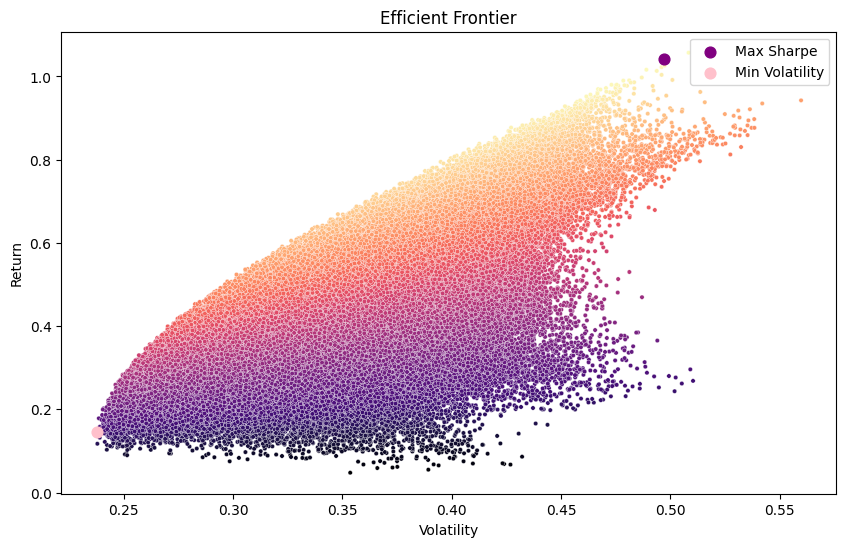

In [12]:
ef = efficientFrontier(tickers=tickers, start_date=START_DATE, end_date=END_DATE)